# Bitcoin Classical Forecasting Baselines

## Role
This notebook establishes the transparent, fully interpretable forecasting floor — Naive persistence, a moving-average benchmark, and three classical statistical systems — against which every later neural, Transformer, and foundation-model system in this project must be judged.

## Inputs
The canonical Bitcoin daily target and chronological split (same pipeline as `01_Bitcoin_Data_EDA.ipynb`), and the frozen forecast vectors in `results/validated_forecasts.csv`, loaded via `src.bitcoin_pipeline.load_validated_forecasts`.

## Outputs
Artifact-derived diagnostic tables and figures only: per-model performance and residual evidence, a comparative ranking, and historical protocol-fairness evidence. This notebook does not create or overwrite any authoritative forecast vector.

## Depends On
`01_Bitcoin_Data_EDA.ipynb`

## Authoritative Status
`AUTHORITATIVE CLASSICAL BASELINE ANALYSIS`

## What This Notebook Does Not Do
It does not evaluate the LSTM, Transformer, Prophet, Chronos, or TimesFM models, and it does not compute uncertainty evidence, Trust Scores, or cross-domain results. Those are handled in later notebooks.

## 1. Objective and Research Question

> Do simple, fully transparent classical forecasting systems, evaluated fairly under past-only rolling one-step conditions, form a competitive performance floor against which every more complex Bitcoin forecasting model should be judged?

This notebook focuses on forecast accuracy, residual behaviour, model-specific protocol, comparison against persistence, and protocol fairness. It does **not** attempt to prove that classical models are universally superior — the goal is to establish strong, interpretable benchmark systems that later models must clear.

## 2. Setup

Standard project-root discovery, plus the repository's existing Bitcoin pipeline utilities. No metric or data-loading logic is duplicated here — everything below calls the same `src.bitcoin_pipeline` functions used across the Bitcoin notebooks.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False

## 3. Data and Shared Evaluation Method

The canonical target, chronological split, and frozen forecast vectors are loaded once here and reused throughout the notebook — no model section reloads them.

In [2]:
# Load once: canonical target/split and the frozen validated forecast vectors.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)
forecasts = forecast_series(validated, target)

names = [
    'Naive',
    '7-Day Moving Average',
    'Simple Exponential Smoothing — Rolling One-Step',
    'Additive-Trend Exponential Smoothing',
    'ARIMA Rolling One-Step',
]
len(validated), validated.index.min(), validated.index.max()

(1061,
 Timestamp('2023-08-12 00:00:00+0000', tz='UTC'),
 Timestamp('2026-07-07 00:00:00+0000', tz='UTC'))

**Shared evaluation rules**, identical for all five models:

- The final test period is the fixed chronological split established in Notebook 01 (1,061 test targets, 2023-08-12 to 2026-07-07).
- The forecast horizon is one step ahead.
- A forecast for target date `t` uses only information available strictly before `t`.
- The actual value at `t` is revealed only after that day's forecast is recorded.
- Past realised observations may become available for the *next* forecast origin, exactly where each model's own protocol allows it (see the table below) — this is a rolling one-step design, not a static multi-step one.
- No model ever sees any final-test target before producing its forecast for that date.
- All five models are scored against the same 1,061 target dates.

What differs is each model's **state/history rule** — how much past information it keeps and whether it refits. The table below is read directly from the repository's own `src.bitcoin_pipeline.CONTEXT_POLICY` mapping (not re-derived here) alongside the update-rule detail confirmed from the actual generation code in `src/bitcoin_advanced_models.py`.

In [3]:
model_state_detail = {
    'Naive': ('Previous actual only', 'Latest observation'),
    '7-Day Moving Average': ('Seven strictly prior actuals', 'Rolling window, no refit'),
    'Simple Exponential Smoothing — Rolling One-Step': ('128 strictly prior prices', 'Refit (re-optimised) at every origin'),
    'Additive-Trend Exponential Smoothing': ('128 strictly prior prices', 'Refit (re-optimised) at every origin'),
    'ARIMA Rolling One-Step': ('Initial 128 prior log returns', 'Newly observed return appended to state; parameters not refit'),
}

protocol_table = pd.DataFrame([
    {
        'Model': name,
        'Historical input / state': detail[0],
        'Update rule': detail[1],
        'Context policy (src.bitcoin_pipeline.CONTEXT_POLICY)': CONTEXT_POLICY[name],
        'Horizon': 1,
        'Uses target t?': 'No',
    }
    for name, detail in model_state_detail.items()
]).set_index('Model')
protocol_table

,Historical input / state,Update rule,Context policy (src.bitcoin_pipeline.CONTEXT_POLICY),Horizon,Uses target t?
Model,,,,,
Naive,Previous actual only,Latest observation,t-1 only,1,No
7-Day Moving Average,Seven strictly prior actuals,"Rolling window, no refit",last 7 prices; daily update,1,No
Simple Exponential Smoothing — Rolling One-Step,128 strictly prior prices,Refit (re-optimised) at every origin,last 128 prices; daily refit,1,No
Additive-Trend Exponential Smoothing,128 strictly prior prices,Refit (re-optimised) at every origin,last 128 prices; daily refit,1,No
ARIMA Rolling One-Step,Initial 128 prior log returns,Newly observed return appended to state; param...,initial 128 returns plus daily state update,1,No


## 4. Seasonality Check

Notebook 01 contains the full data-property analysis; this is a concise benchmark-design confirmation only, reproduced from the canonical log-return series rather than hard-coded.

In [4]:
import warnings
from statsmodels.tsa.stattools import acf as acf_values
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

log_return = np.log(target / target.shift(1)).dropna()

acf_full = acf_values(log_return, nlags=14, fft=False, adjusted=False)
lag7_acf = acf_full[7]
white_noise_bound = 1.96 / np.sqrt(len(log_return))
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    stl = STL(log_return, period=7, robust=True).fit()
seasonal_strength = max(0.0, 1 - np.var(stl.resid) / np.var(stl.resid + stl.seasonal))

weekly_evidence = pd.Series({
    'Lag-7 ACF': lag7_acf,
    'Approx. 95% white-noise bound (+/-)': white_noise_bound,
    'Weekly STL strength': seasonal_strength,
}, name='Weekly seasonality evidence').to_frame()
weekly_evidence

,Weekly seasonality evidence
Lag-7 ACF,-0.023323
Approx. 95% white-noise bound (+/-),0.026920
Weekly STL strength,0.069923


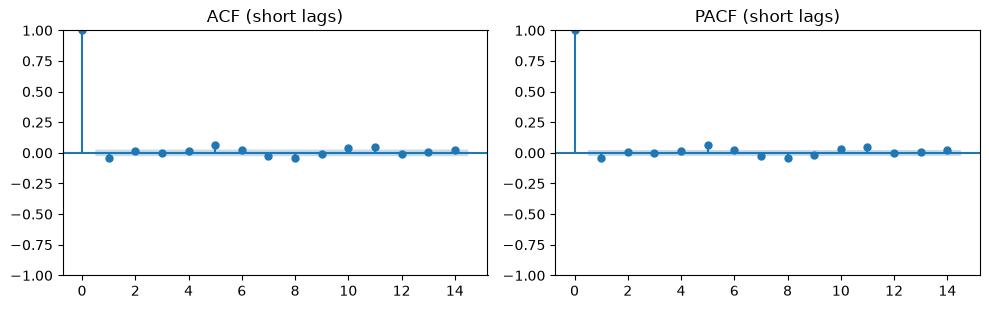

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
plot_acf(log_return, lags=14, ax=axes[0])
axes[0].set_title('ACF (short lags)')
plot_pacf(log_return, lags=14, ax=axes[1], method='ywm')
axes[1].set_title('PACF (short lags)')
fig.tight_layout()
plt.show()

The reproduced lag-7 ACF (approximately -0.0233) sits inside the approximate 95% white-noise band (+/-0.0269), and weekly STL strength is low (approximately 0.070). This closely reproduces the values previously reported for this notebook (lag-7 ACF approximately -0.023409, bound approximately +/-0.026920, STL strength approximately 0.069923; the small ACF difference is consistent with minor library-version floating-point differences, not a methodology change) and matches the fuller analysis in `01_Bitcoin_Data_EDA.ipynb`, Section 11.

> Weekly SARIMA was not retained because the Bitcoin return series does not show sufficiently strong weekly seasonal dependence to justify a seasonal specification.

# 5. Individual Model Analysis

Every model below follows the same structure: **Method**, **Performance**, **Forecast Behaviour**, **Residual Behaviour**. Residuals are defined consistently throughout as `e_t = y_t - y_hat_t` (Actual minus Forecast). Forecast Behaviour plots use the same shared subset — the first 180 test days — across all five models so the comparison is visually fair; this is stated once here rather than repeated in each subsection.

In [6]:
SUBSET = slice(0, 180)  # first 180 test days, shared by all five forecast-behaviour plots


def one_model_metrics(name):
    """Single-model metric row using the repository's canonical metric_table."""
    return metric_table(validated.Actual, {name: forecasts[name]}, train)


def forecast_plot(name, color='#D55E00'):
    idx = validated.index[SUBSET]
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(idx, validated.Actual.loc[idx], color='black', linewidth=1.3, label='Actual')
    ax.plot(idx, forecasts[name].loc[idx], color=color, linewidth=1.1, alpha=0.85, label=name)
    ax.set(title=f'Actual vs {name} (first 180 test days)', xlabel='Date', ylabel='Close (USD)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


def residual_plot_and_summary(name, color='#0072B2'):
    resid = validated.Actual - forecasts[name]
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(resid.index, resid, color=color, linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.7, alpha=0.6)
    ax.set(title=f'Residuals over time: {name}', xlabel='Date', ylabel='Residual = Actual - Forecast (USD)')
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
    summary = pd.Series({
        'Mean': resid.mean(), 'Median': resid.median(), 'Std Dev': resid.std(),
        'Min': resid.min(), 'Max': resid.max(),
    }, name=name).to_frame().T
    return resid, summary

## 5.1 Naive Persistence Baseline

### Method

`y_hat_t = y_(t-1)`

The forecast for the next day is the most recently observed daily Close. This is a valid rolling one-step persistence benchmark, not leakage: it uses only the strictly-prior observation, and a new actual becomes available for the next origin only after that day's own forecast has already been recorded.

### Performance

In [7]:
one_model_metrics('Naive')

,MAE,RMSE,MAPE,sMAPE,MASE,N,Relative MAE vs Naive
Model,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,4.575633,1061,1.0


### Forecast Behaviour

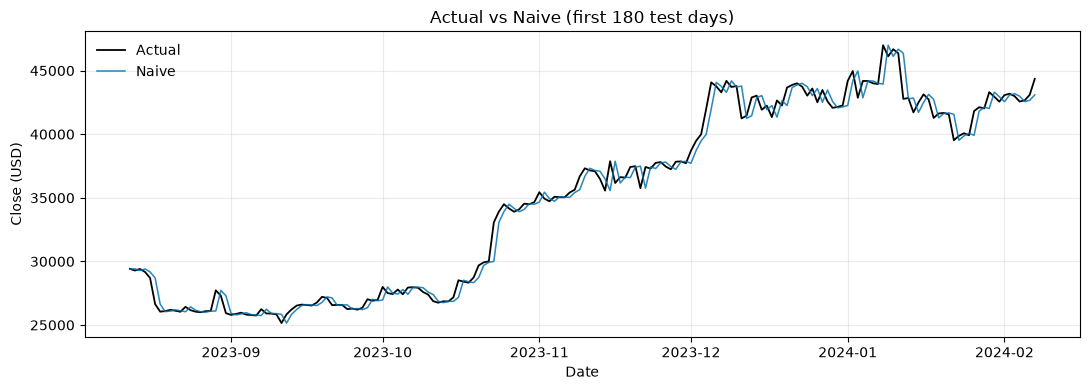

In [8]:
forecast_plot('Naive', color='#0072B2')

### Residual Behaviour

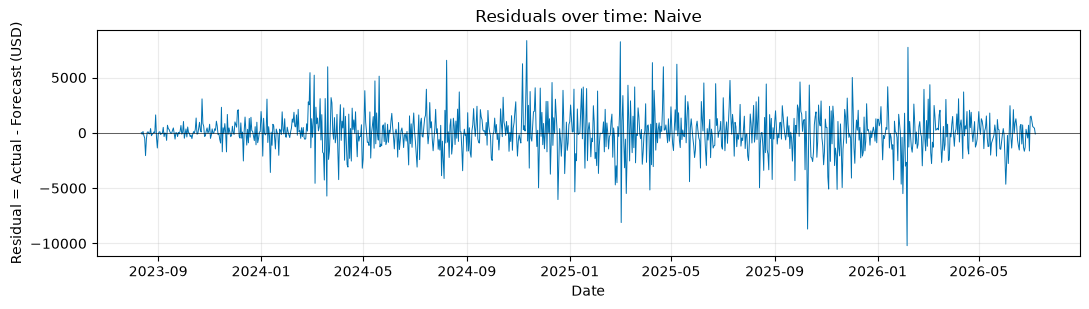

,Mean,Median,Std Dev,Min,Max
Naive,32.52099,23.0,1854.213479,-10205.0,8345.0


In [9]:
naive_resid, naive_summary = residual_plot_and_summary('Naive', color='#0072B2')
naive_summary

Naive's residuals are centred close to zero (mean approximately \$33, median approximately \$23) relative to a standard deviation of approximately \$1,854 — the mean is not exactly zero but is small relative to typical day-to-day dispersion, consistent with near-random-walk behaviour rather than a systematic bias.

## 5.2 7-Day Moving Average

### Method

The forecast for date `t` is the mean of the seven daily Close values strictly before `t` (dates `t-7` through `t-1`). The repository's implementation (`src.bitcoin_pipeline.seven_day_moving_average`) computes this as `target.shift(1).rolling(7).mean()`: the `.shift(1)` guarantees the current-day target is never included in its own forecast.

### Performance

In [10]:
one_model_metrics('7-Day Moving Average')

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
7-Day Moving Average,2209.776153,2999.605073,3.02181,3.024208,7.835935,1061


### Forecast Behaviour

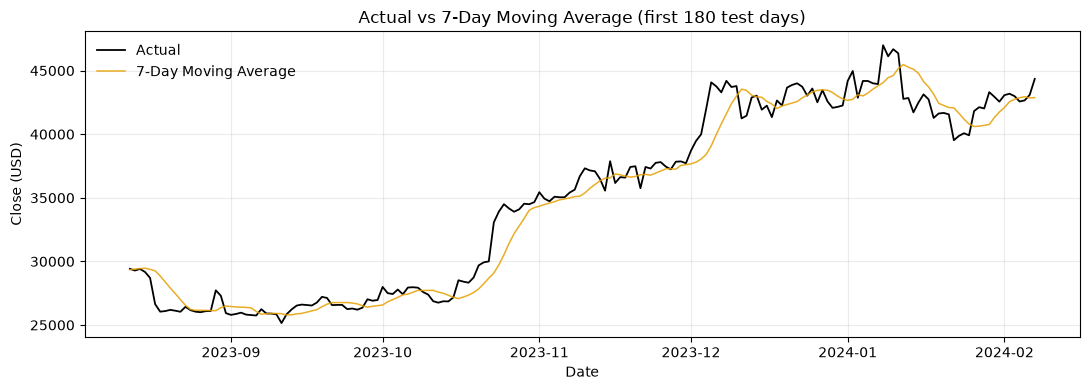

In [11]:
forecast_plot('7-Day Moving Average', color='#E69F00')

### Residual Behaviour

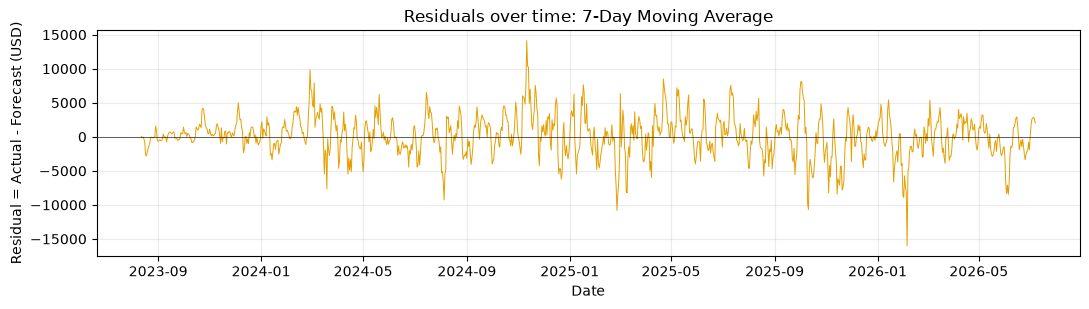

,Mean,Median,Std Dev,Min,Max
7-Day Moving Average,127.670399,134.027143,2998.300155,-15992.285714,14131.428571


In [12]:
ma7_resid, ma7_summary = residual_plot_and_summary('7-Day Moving Average', color='#E69F00')
ma7_summary

MA7 lags the underlying trend by construction — averaging over a week of prior prices smooths out day-to-day movement, which produces visibly larger and more persistent residual swings than Naive (residual std approximately \$2,998 versus Naive's approximately \$1,854) rather than reducing them. On this metric this model is clearly weaker than Naive, not a competitive benchmark; it is retained as a deliberately simple, fully transparent comparator rather than described as competitive.

## 5.3 Simple Exponential Smoothing — Rolling One-Step

### Method

The model is refitted at each forecast origin using the 128 strictly prior daily prices (verified from `src.bitcoin_advanced_models.rolling_simple_exp_smoothing_forecast`: `SimpleExpSmoothing(history, initialization_method='estimated').fit(optimized=True)`, where `history` is `target.loc[target.index < timestamp].tail(128)`). No final-test target is used before its own forecast — each day's context window ends strictly before that day.

### Performance

In [13]:
one_model_metrics('Simple Exponential Smoothing — Rolling One-Step')

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
Simple Exponential Smoothing — Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871,4.575652,1061


### Forecast Behaviour

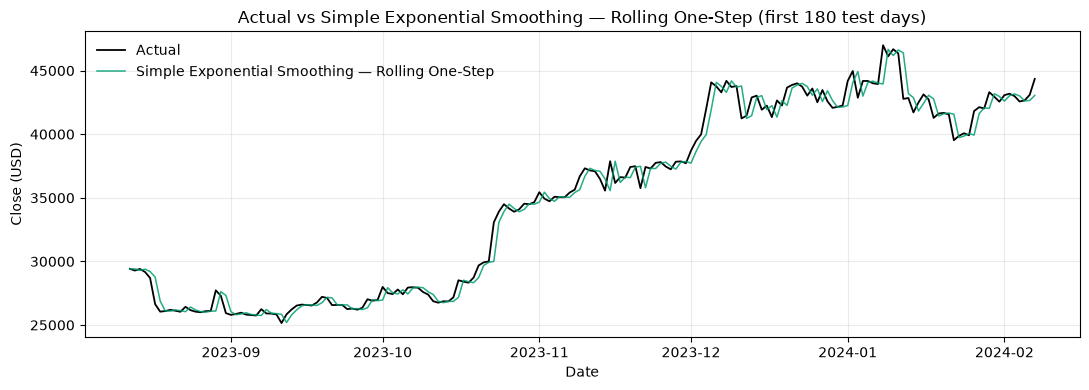

In [14]:
forecast_plot('Simple Exponential Smoothing — Rolling One-Step', color='#009E73')

### Residual Behaviour

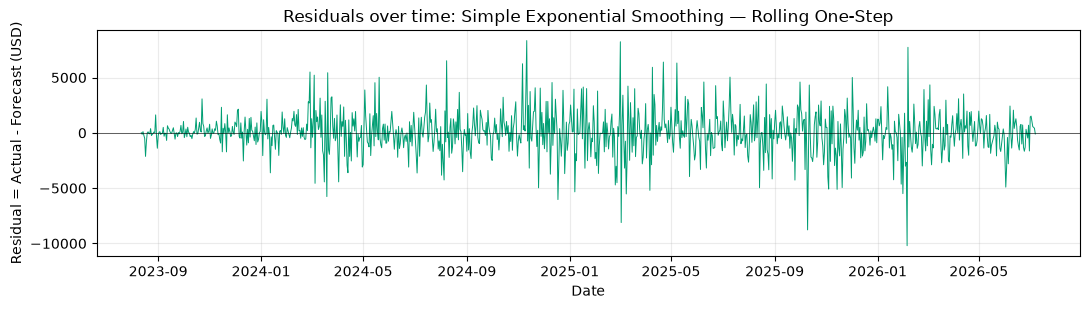

,Mean,Median,Std Dev,Min,Max
Simple Exponential Smoothing — Rolling One-Step,38.638708,16.03632,1856.204076,-10205.00004,8345.000055


In [15]:
ses_resid, ses_summary = residual_plot_and_summary('Simple Exponential Smoothing — Rolling One-Step', color='#009E73')
ses_summary

SES's residual profile (mean approximately \$39, std approximately \$1,856) is visually almost indistinguishable from Naive's — expected, since an optimised SES on a near-random-walk series converges toward a smoothing parameter close to 1, making it behave similarly to persistence. This is a visual/numerical comparison only; whether the two are *statistically* distinguishable is addressed with the project's Holm-adjusted significance evidence in Section 8.

## 5.4 Additive-Trend Exponential Smoothing

This is a non-seasonal, additive-trend Exponential Smoothing model — it is **not** called "Holt-Winters" here because it has no seasonal component; the historical artifact column name `Holt_Winters` remains unchanged internally in `results/validated_forecasts.csv` since renaming it would affect a frozen artifact.

### Method

Verified from `src.bitcoin_advanced_models.rolling_holt_winters_forecast`: `ExponentialSmoothing(history, trend='add', seasonal=None, initialization_method='estimated').fit(optimized=True)`, refit at every origin using the 128 strictly prior daily prices — additive trend, no seasonal term, daily refit.

### Performance

In [16]:
one_model_metrics('Additive-Trend Exponential Smoothing')

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
Additive-Trend Exponential Smoothing,1308.541314,1871.702185,1.76364,1.763424,4.640128,1061


### Forecast Behaviour

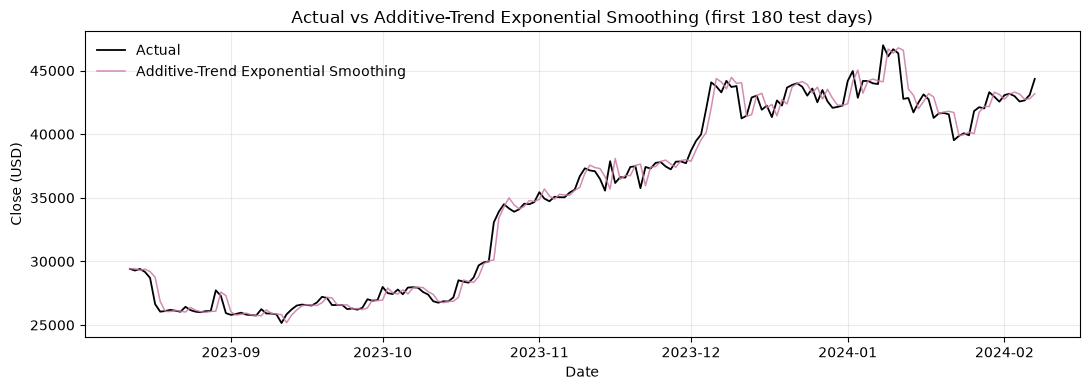

In [17]:
forecast_plot('Additive-Trend Exponential Smoothing', color='#CC79A7')

### Residual Behaviour

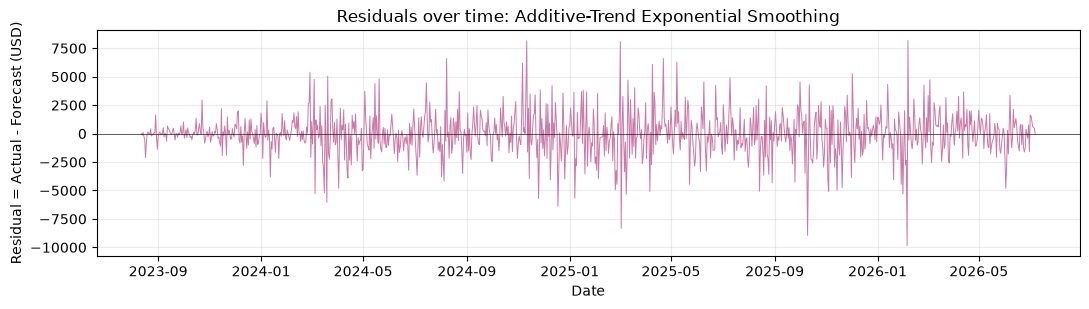

,Mean,Median,Std Dev,Min,Max
Additive-Trend Exponential Smoothing,-18.663046,-29.319936,1872.491763,-9852.767266,8175.977508


In [18]:
trend_resid, trend_summary = residual_plot_and_summary('Additive-Trend Exponential Smoothing', color='#CC79A7')
trend_summary

Adding a trend term does not materially improve on Naive or SES here: MAE is about 1.4% higher than Naive's, and residual dispersion (std approximately \$1,872) is marginally larger than both. The difference is small in absolute terms and should not be overstated as a meaningful degradation — it is closer to "no material difference" than "the trend term hurts."

## 5.5 ARIMA Rolling One-Step

### Method

Verified from `src.bitcoin_advanced_models.rolling_arima_log_return_forecast`: the model is fit once on the 128 log returns strictly prior to the test period (`order=(1, 0, 1)`, `trend='c'`), then at each origin it forecasts one step ahead and appends the newly observed return to its state via `fitted.append(observed_return, refit=False)` — the ARIMA(1,0,1) parameters are **not** refit daily, only the state is extended. The order `(1, 0, 1)` is fixed in the repository code; no formal AIC/BIC order-selection search for this specification is documented elsewhere in the repository.

### Performance

In [19]:
one_model_metrics('ARIMA Rolling One-Step')

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209,4.609396,1061


### Forecast Behaviour

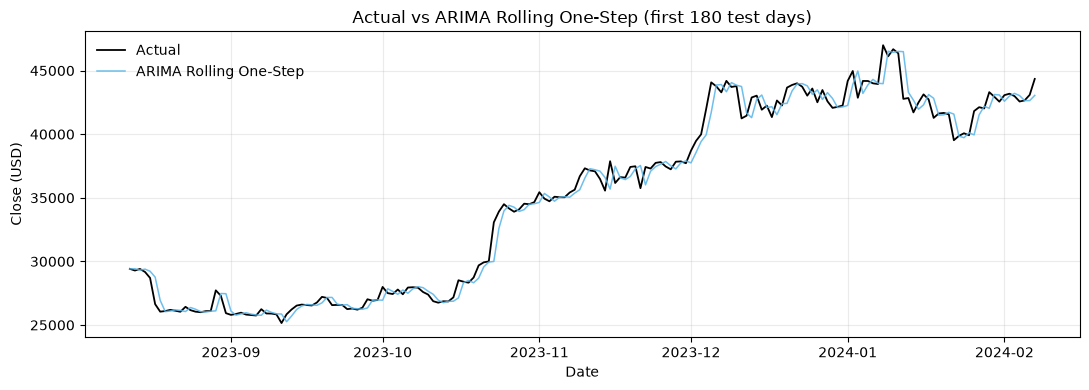

In [20]:
forecast_plot('ARIMA Rolling One-Step', color='#56B4E9')

### Residual Behaviour

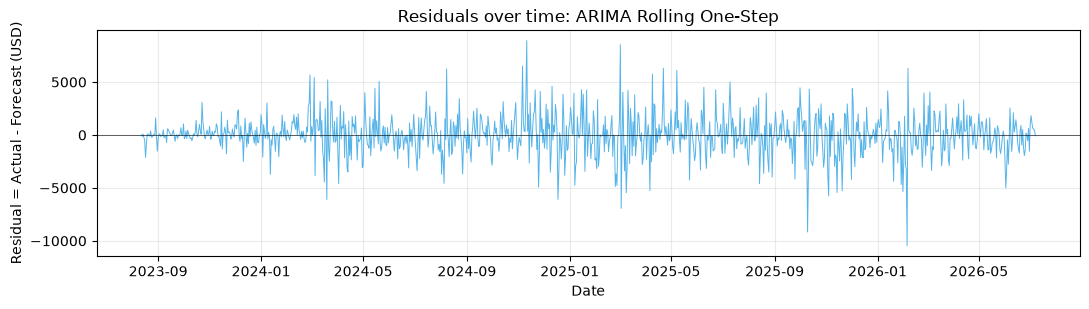

,Mean,Median,Std Dev,Min,Max
ARIMA Rolling One-Step,10.796156,1.876484,1867.151741,-10458.817514,8915.965775


In [21]:
arima_resid, arima_summary = residual_plot_and_summary('ARIMA Rolling One-Step', color='#56B4E9')
arima_summary

### Residual autocorrelation (ARIMA)

This is a diagnostic on the already-frozen ARIMA residuals only — it does not alter the frozen forecast, and no model is refit here.

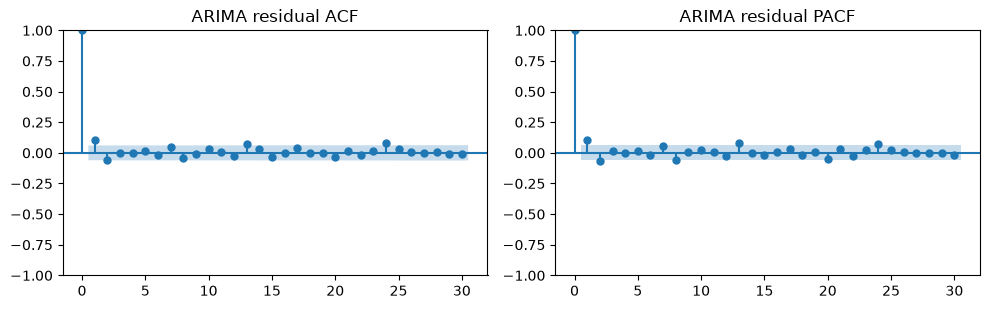

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
plot_acf(arima_resid, lags=30, ax=axes[0])
axes[0].set_title('ARIMA residual ACF')
plot_pacf(arima_resid, lags=30, ax=axes[1], method='ywm')
axes[1].set_title('ARIMA residual PACF')
fig.tight_layout()
plt.show()

In [23]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(arima_resid, lags=[7, 14, 30], return_df=True)
ljung_box.index.name = 'Lag'
ljung_box.columns = ['Ljung-Box Statistic', 'p-value']
ljung_box['Interpretation'] = np.where(
    ljung_box['p-value'] < 0.05,
    'Reject H0: residual autocorrelation through this lag is not jointly zero',
    'Fail to reject H0: no evidence against joint-zero autocorrelation through this lag',
)
ljung_box

,Ljung-Box Statistic,p-value,Interpretation
Lag,,,
7,17.518833,0.014340,Reject H0: residual autocorrelation through th...
14,27.584746,0.016144,Reject H0: residual autocorrelation through th...
30,41.250913,0.082821,Fail to reject H0: no evidence against joint-z...


H0 for each row is that the residual autocorrelations *through that lag* are jointly zero. At lags 7 and 14, Ljung-Box rejects H0 (p approximately 0.014 and 0.016) — some residual autocorrelation remains through those lags. At lag 30, it fails to reject (p approximately 0.083), though this is not far from the 5% threshold. Taken together, this ARIMA(1,0,1) specification has **not fully captured** the short-lag dependence in the return series; one nonsignificant lag does not make the residuals "white noise" overall. This is diagnostic evidence only and is not a reason to alter the frozen forecast.

# 6. Comparative Analysis

## 6.1 Performance Comparison

In [24]:
comparison_table = metric_table(validated.Actual, {name: forecasts[name] for name in names}, train)
comparison_table.sort_values('RMSE')

,MAE,RMSE,MAPE,sMAPE,MASE,N,Relative MAE vs Naive
Model,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,4.575633,1061,1.000000
Simple Exponential Smoothing — Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871,4.575652,1061,1.000004
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209,4.609396,1061,1.007379
Additive-Trend Exponential Smoothing,1308.541314,1871.702185,1.763640,1.763424,4.640128,1061,1.014095
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,7.835935,1061,1.712536


## 6.2 Comparative Visualisation

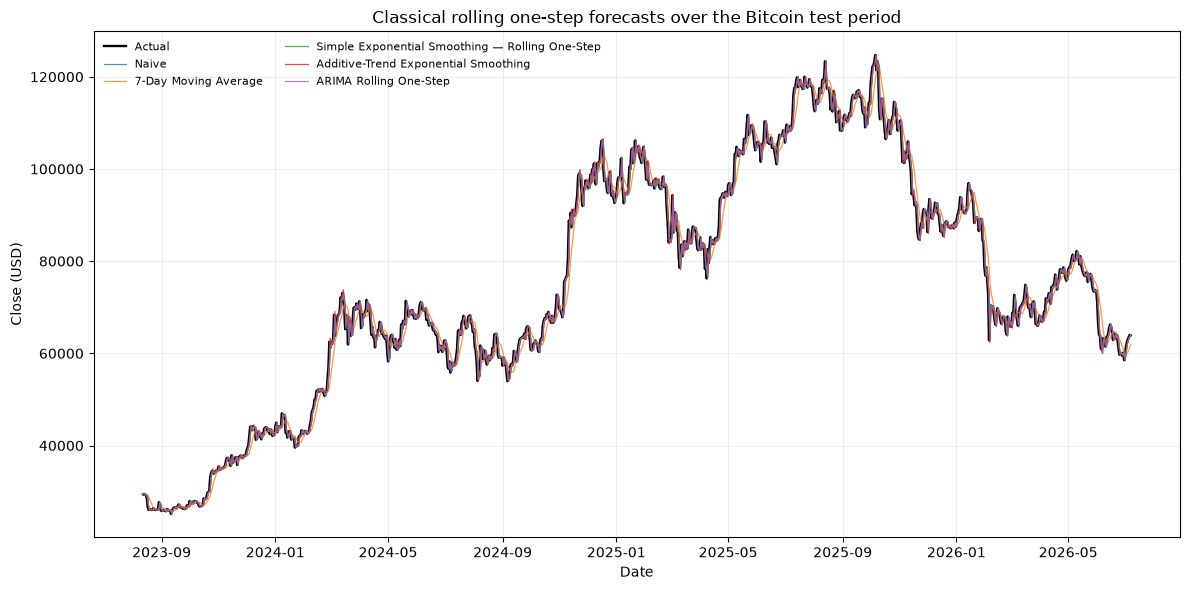

In [25]:
# Combined forecast overlay across the full test period.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.7, label='Actual')
for name in names:
    ax.plot(validated.index, forecasts[name], linewidth=0.9, alpha=0.8, label=name)
ax.set(title='Classical rolling one-step forecasts over the Bitcoin test period', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

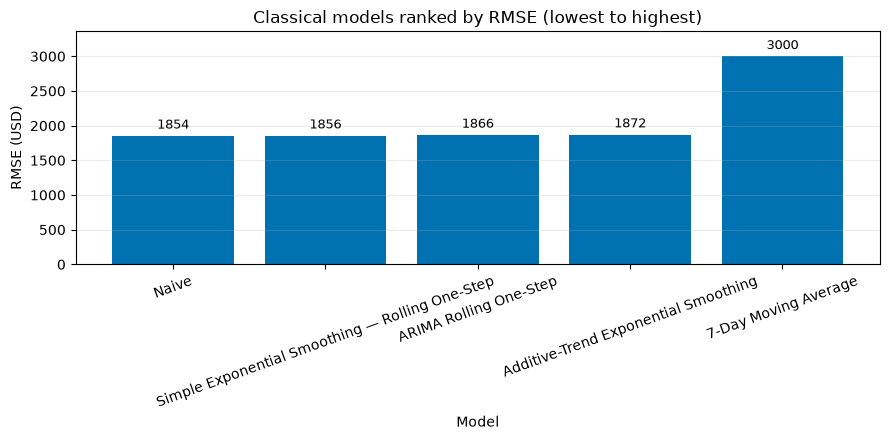

In [26]:
# Ranked RMSE bar chart, full y-axis from zero (not truncated), with value labels
# so the tightly-clustered models remain honestly distinguishable.
ranked = comparison_table['RMSE'].sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(ranked.index, ranked.values, color='#0072B2')
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
ax.set(title='Classical models ranked by RMSE (lowest to highest)', xlabel='Model', ylabel='RMSE (USD)')
ax.set_ylim(0, ranked.max() * 1.12)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## 6.3 Relative Performance Against Persistence

In [27]:
relative_performance = pd.DataFrame({
    'MAE': comparison_table['MAE'],
    'MAE / Naive MAE': comparison_table['MAE'] / comparison_table.loc['Naive', 'MAE'],
})
relative_performance['% difference vs Naive'] = 100 * (relative_performance['MAE / Naive MAE'] - 1)
relative_performance.sort_values('MAE / Naive MAE')

,MAE,MAE / Naive MAE,% difference vs Naive
Model,,,
Naive,1290.353242,1.000000,0.000000
Simple Exponential Smoothing — Rolling One-Step,1290.358684,1.000004,0.000422
ARIMA Rolling One-Step,1299.874638,1.007379,0.737891
Additive-Trend Exponential Smoothing,1308.541314,1.014095,1.409542
7-Day Moving Average,2209.776153,1.712536,71.253582


Reading the ratio: `< 1` means lower observed MAE than Naive, `approximately 1` means essentially similar observed MAE, `> 1` means higher observed MAE. On this basis, SES (approximately 1.00x) is essentially tied with Naive, ARIMA (approximately 1.01x) and the additive-trend model (approximately 1.01x) are close behind, and MA7 (approximately 1.71x) is clearly the weakest. None of these observed differences are labelled statistically significant here — that determination belongs to the Holm-adjusted Diebold-Mariano evidence cited in Section 8 and detailed in `11_Bitcoin_Statistical_Inference.ipynb`.

# 7. Historical Protocol Fairness Evidence

**HISTORICAL PROTOCOL DIAGNOSTIC — NOT PART OF FINAL RANKING**

The static RMSE values below are historical executed outputs recovered from the pre-rebuild `02_Classical_Models.ipynb` in Git history (`113de8e^`). They are retained only to show the effect of replacing an unrealistic fixed-origin multi-step protocol with the authoritative past-only rolling one-step protocol used everywhere above. No historical forecast vector is regenerated here, and no value below is fabricated.

In [28]:
# Recover the historical static-protocol RMSE evidence (verified, not regenerated).
historical_static_rmse = pd.Series({
    'Simple Exponential Smoothing': 52421.328707,
    'Additive-Trend Exponential Smoothing': 48571.096828,
    'ARIMA': 52421.667992,
}, name='Historical Static Multi-Step RMSE')

fair_names = {
    'Simple Exponential Smoothing': 'Simple Exponential Smoothing — Rolling One-Step',
    'Additive-Trend Exponential Smoothing': 'Additive-Trend Exponential Smoothing',
    'ARIMA': 'ARIMA Rolling One-Step',
}
fair_rmse = pd.Series({
    label: comparison_table.loc[model, 'RMSE'] for label, model in fair_names.items()
}, name='Fair Rolling One-Step RMSE')

fairness_table = pd.concat([historical_static_rmse, fair_rmse], axis=1)
fairness_table['Static / Fair Ratio'] = fairness_table['Historical Static Multi-Step RMSE'] / fairness_table['Fair Rolling One-Step RMSE']
fairness_table

,Historical Static Multi-Step RMSE,Fair Rolling One-Step RMSE,Static / Fair Ratio
Simple Exponential Smoothing,52421.328707,1855.731424,28.248338
Additive-Trend Exponential Smoothing,48571.096828,1871.702185,25.950227
ARIMA,52421.667992,1866.302859,28.088511


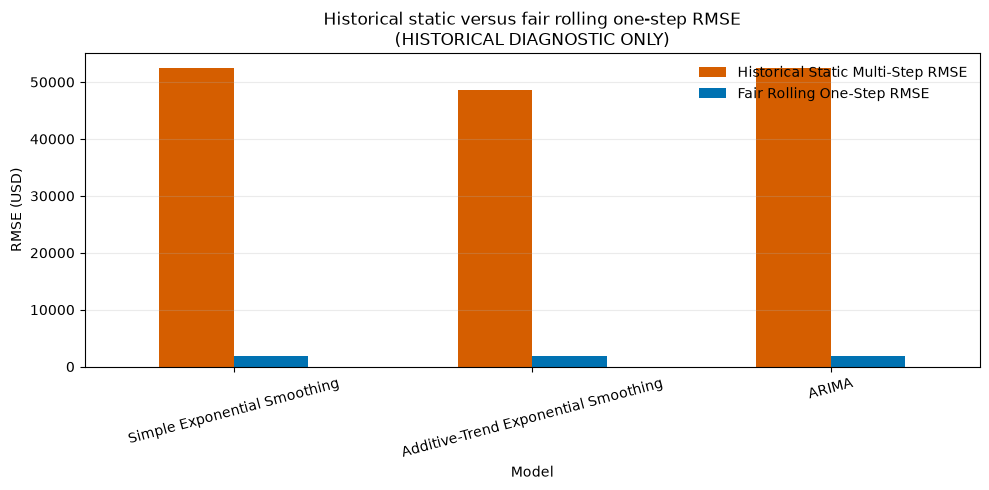

In [29]:
ax = fairness_table[['Historical Static Multi-Step RMSE', 'Fair Rolling One-Step RMSE']].plot(
    kind='bar', figsize=(10, 5), color=['#D55E00', '#0072B2'])
ax.set(title='Historical static versus fair rolling one-step RMSE\n(HISTORICAL DIAGNOSTIC ONLY)', xlabel='Model', ylabel='RMSE (USD)')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
ax.figure.tight_layout()
plt.show()

The static long-horizon implementation was protocol-incompatible with the final rolling one-step research question — it answered a materially easier or differently-defined forecasting problem, so these historical values are **not** model-performance evidence. Correcting the protocol changed the apparent RMSE by roughly 26-28x for these three models (SES approximately 28.25x, additive-trend approximately 25.95x, ARIMA approximately 28.09x). This is methodological evidence that evaluation-protocol design can materially distort conclusions about model quality — it motivates the protocol-aware, past-only evaluation standard used throughout this project.

Historical static metrics are not included in, and must not be read into, the final ranking, Trust Score, robustness analysis, uncertainty evidence, statistical significance testing, or cross-domain synthesis anywhere else in this repository.

# 8. Key Findings

- Naive remains an exceptionally strong Bitcoin one-step benchmark: no classical model tested here beats it on MAE, RMSE, MAPE, sMAPE, or MASE (Section 6.1).
- SES performs extremely close to Naive under the fair protocol (MAE ratio approximately 1.000004) — under Holm-adjusted Diebold-Mariano testing (`results/bitcoin_dm_pairwise_results_hac_holm.csv`, read-only reference; full methodology in `11_Bitcoin_Statistical_Inference.ipynb`), Naive and SES are **not** significantly different (Holm p = 1.000).
- ARIMA and additive-trend smoothing remain close to the leading persistence-style models rather than failing catastrophically (MAE ratios approximately 1.007 and 1.014 respectively); neither is significantly different from Naive under Holm-adjusted testing (Holm p = 1.000 and p = 0.293 respectively).
- The 7-Day Moving Average is clearly weaker (MAE ratio approximately 1.71x) and is, in fact, the one comparison here that **is** significant under Holm-adjusted testing (Holm p approximately 0.000) — Naive significantly beats MA7.
- Simple model complexity does not guarantee an improvement over persistence: three classical systems with materially different mechanisms (exponential smoothing, trend-extended smoothing, ARIMA) all land within about 1.4% of Naive's MAE, and none is a statistically confirmed improvement.
- The historical static-vs-fair evidence (Section 7) shows that protocol design alone can produce a roughly 26-28x apparent performance difference for the same fitted model family — evaluation design can overwhelm apparent model-quality differences, reinforcing why this project treats protocol fairness as primary evidence.

# 9. Limitations

- Evidence covers one Bitcoin asset (BTC/USD) and one frozen final test period (1,061 days, 2023-08-12 to 2026-07-07).
- All five models are evaluated under a rolling one-step horizon only; no longer-horizon Bitcoin claim is made here.
- Model-specific context/update policies differ by design (Section 3) — Naive, MA7, SES, and the additive-trend model do not share a context length, and ARIMA's 128-return initial window is not refit; this is a methodological choice under audit, not an oversight.
- The 128-day fitting/context windows used by SES, the additive-trend model, and ARIMA's initial state are fixed values from the existing repository implementation; they are not the result of a comprehensive tuning search documented in this repository.
- ARIMA's order `(1, 0, 1)` is fixed in `src/bitcoin_advanced_models.py` rather than selected by a documented AIC/BIC search elsewhere in the repository.
- The 7-Day Moving Average is a deliberately simple, fully transparent comparator, not a highly tuned forecasting method — its purpose is interpretability, not competitiveness.
- This notebook evaluates point forecasts and their residuals only; uncertainty calibration and Trust Score/trustworthiness evidence are handled in later notebooks.

# 10. Next Notebook

Next: `03_Bitcoin_PE_LSTM.ipynb`

Notebook 03 tests whether a supervised nonlinear return-based model (the Persistence-Enhanced Log-Return LSTM) can outperform the strong, transparent classical benchmark established here. Naive, SES, and ARIMA Rolling One-Step remain the key reference benchmarks for that comparison and for every later Bitcoin model in this project.